In [1]:
import uuid
import shutil
import os, glob
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
print("TF version:", tf.__version__)
import matplotlib.pyplot as plt
from seaborn import heatmap, color_palette
from sklearn.metrics import confusion_matrix, classification_report


TF version: 2.15.0


In [2]:
train_dataset_dir = 'data/train'
test_dataset_dir = 'data/test'
validation_dataset_dir = 'data/validation'

width = 224
height = 224

target_size = (width, height)
input_shape = (width, height, 3)

In [3]:
# create data splits

def create_splits(
                test_size = 0.15
                , validation_size = 0.15
                ):
    all_images = glob.glob(f'{train_dataset_dir}/*/*.*')
    np.random.shuffle(all_images)

    test_size = int(len(all_images) * test_size)
    validation_size = int(len(all_images) * validation_size)

    test_images = all_images[:test_size]
    validation_images = all_images[test_size:test_size+validation_size]
    
    # copy images to test directory
    for image in test_images:
        image = image.replace('\\', '/')
        image_name = image.split('/')[-1]
        image_class = image.split('/')[-2]
        image_class_dir = f'{test_dataset_dir}/{image_class}'
        if not os.path.exists(image_class_dir):
            os.makedirs(image_class_dir)
        shutil.copy(image, f'{image_class_dir}/{image_name}')
        
    # copy images to validation directory
    for image in validation_images:
        image = image.replace('\\', '/')
        image_name = image.split('/')[-1]
        image_class = image.split('/')[-2]
        image_class_dir = f'{validation_dataset_dir}/{image_class}'
        if not os.path.exists(image_class_dir):
            os.makedirs(image_class_dir)
        shutil.copy(image, f'{image_class_dir}/{image_name}')

# create_splits()

In [4]:
def preprocessing_function(img, pretrained = False):
    if pretrained:
        img = tf.keras.applications.xception.preprocess_input(img)
    else:
        img = img.astype(np.float32)
        img = img / 255.0
        
    return img

def image_data_generator():
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                                                                    rotation_range = 30,
                                                                    shear_range = 0.3,
                                                                    zoom_range = 0.3,
                                                                    width_shift_range=0.3,
                                                                    height_shift_range=0.3,
                                                                    horizontal_flip = True,
                                                                    preprocessing_function=preprocessing_function
                                                                    )
    
    val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                                                                    preprocessing_function=preprocessing_function       
                                                                    )
    
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
                                                                    preprocessing_function=preprocessing_function
                                                                    )

    train_generator = train_datagen.flow_from_directory(
                                                        train_dataset_dir,
                                                        target_size = target_size,
                                                        color_mode = 'rgb',
                                                        batch_size = 16,
                                                        class_mode = 'binary',
                                                        shuffle = True
                                                        )
    
    validation_generator = val_datagen.flow_from_directory(
                                                        validation_dataset_dir,
                                                        target_size = target_size,
                                                        color_mode = 'rgb',
                                                        batch_size = 16,
                                                        class_mode = 'binary',
                                                        shuffle = True
                                                        )
    
    test_generator = test_datagen.flow_from_directory(
                                                        test_dataset_dir,           
                                                        target_size = target_size,
                                                        color_mode = 'rgb',
                                                        batch_size = 16,
                                                        class_mode = 'binary',
                                                        shuffle = False
                                                        )
    return train_generator, validation_generator, test_generator

In [8]:
train_generator, validation_generator, test_generator = image_data_generator()

Found 24576 images belonging to 2 classes.
Found 6802 images belonging to 2 classes.
Found 6823 images belonging to 2 classes.


In [9]:
def cancer_detector(pretrained = True):   
    if pretrained: 
        model = tf.keras.applications.Xception(
                                                include_top=False,
                                                weights='imagenet',
                                                input_shape=input_shape
                                                )
        model.trainable = True
        model = tf.keras.Sequential([
                                    tf.keras.layers.InputLayer(input_shape=input_shape),
                                    model,
                                    tf.keras.layers.GlobalAveragePooling2D(),
                                    tf.keras.layers.Dense(256, activation='softmax'),
                                    tf.keras.layers.Dense(64, activation='softmax'),
                                    tf.keras.layers.Dense(1, activation='sigmoid')
                                    ])

    else:
        model = tf.keras.models.Sequential([
                                            tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),      
                                            tf.keras.layers.MaxPooling2D(2,2),
                                            tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
                                            tf.keras.layers.MaxPooling2D(2,2),
                                            tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
                                            tf.keras.layers.MaxPooling2D(2,2),

                                            tf.keras.layers.Flatten(),
                                            tf.keras.layers.Dense(512, activation='relu'),
                                            tf.keras.layers.Dense(64, activation='relu'),
                                            tf.keras.layers.Dense(1, activation='sigmoid')
                                            ])
    model.summary()
    return model

In [10]:
MODEL_PATH = "cancer_detector.h5"

print("Current working directory:", os.getcwd())
print("Checking if model file exists...")

# ============================================================
# Build Model
# ============================================================

print("Building model...")
model = cancer_detector()

print("Compiling model (initial compile)...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# ============================================================
# Training Section
# ============================================================

if not os.path.exists(MODEL_PATH):

    print("Model file NOT found. Starting training...")

    try:
        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            steps_per_epoch=train_generator.samples // train_generator.batch_size,
            validation_steps=validation_generator.samples // validation_generator.batch_size,
            epochs=30,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss',
                    patience=20,
                    restore_best_weights=True
                )
            ]
        )

        print("Training completed successfully.")
        print("Saving model to:", MODEL_PATH)

        model.save(MODEL_PATH)

        print("Model saved successfully.")

    except Exception as e:
        print("❌ Error occurred during training:")
        print(str(e))

else:
    print("Model file already exists. Skipping training.")

# ============================================================
# Loading Section
# ============================================================

print("Loading model from:", MODEL_PATH)

try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully.")

except Exception as e:
    print("❌ Error while loading model:")
    print(str(e))
    raise e

print("Recompiling loaded model...")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Model ready for inference or further training.")

Current working directory: C:\Personal Projects\BreastCancerDetection-UWS\src\Web\BreastCancerPredictionManager
Checking if model file exists...
Building model...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 7, 7, 2048)        20861480  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 256)               524544    
                                                                 
 dense_4 (Dense)             (None, 64)                16448     
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                       

In [11]:
model.evaluate(validation_generator)


426/426 [==============================] - 385s 899ms/step - loss: 0.1081 - accuracy: 0.9693 - precision: 0.9552 - recall: 0.9919


[0.10812997817993164,
 0.9692737460136414,
 0.9551524519920349,
 0.9918890595436096]

In [12]:
# ============================================================
# Safety Check
# ============================================================

if history is None:
    raise ValueError("❌ 'history' object is None. Model was not trained.")

if not hasattr(history, "history"):
    raise ValueError("❌ Invalid history object.")

print("Available history keys:", history.history.keys())

# ============================================================
# Helper function to safely extract metric
# ============================================================

def get_metric(metric_name):
    if metric_name in history.history:
        return history.history[metric_name]
    else:
        print(f"⚠ Warning: '{metric_name}' not found in history.")
        return None


# ============================================================
# Extract Metrics Safely
# ============================================================

train_accuracy = get_metric('accuracy')
train_precision = get_metric('precision')
train_recall = get_metric('recall')
train_loss = get_metric('loss')

val_accuracy = get_metric('val_accuracy')
val_precision = get_metric('val_precision')
val_recall = get_metric('val_recall')
val_loss = get_metric('val_loss')

# ============================================================
# Optional: Smooth curves (moving average)
# ============================================================

def smooth_curve(values):
    if values is None:
        return None
    return np.cumsum(values) / np.arange(1, len(values) + 1)

train_accuracy = smooth_curve(train_accuracy)
train_precision = smooth_curve(train_precision)
train_recall = smooth_curve(train_recall)
train_loss = smooth_curve(train_loss)

val_accuracy = smooth_curve(val_accuracy)
val_precision = smooth_curve(val_precision)
val_recall = smooth_curve(val_recall)
val_loss = smooth_curve(val_loss)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(12, 10))

# Accuracy
plt.subplot(2, 2, 1)
if train_accuracy is not None:
    plt.plot(train_accuracy, label='Train Accuracy')
if val_accuracy is not None:
    plt.plot(val_accuracy, label='Validation Accuracy')
plt.ylim([0, 1])
plt.title('Accuracy')
plt.legend()

# Precision
plt.subplot(2, 2, 2)
if train_precision is not None:
    plt.plot(train_precision, label='Train Precision')
if val_precision is not None:
    plt.plot(val_precision, label='Validation Precision')
plt.ylim([0, 1])
plt.title('Precision')
plt.legend()

# Recall
plt.subplot(2, 2, 3)
if train_recall is not None:
    plt.plot(train_recall, label='Train Recall')
if val_recall is not None:
    plt.plot(val_recall, label='Validation Recall')
plt.ylim([0, 1])
plt.title('Recall')
plt.legend()

# Loss
plt.subplot(2, 2, 4)
if train_loss is not None:
    plt.plot(train_loss, label='Train Loss')
if val_loss is not None:
    plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

In [15]:
model.evaluate(test_generator)

427/427 [==============================] - 362s 846ms/step - loss: 0.1018 - accuracy: 0.9714 - precision: 0.9582 - recall: 0.9927


[0.10180544853210449,
 0.971420168876648,
 0.9582082033157349,
 0.9927404522895813]

427/427 [==============================] - 344s 805ms/step
              precision    recall  f1-score   support

      benign       0.99      0.94      0.97      2966
   malignant       0.96      0.99      0.98      3857

    accuracy                           0.97      6823
   macro avg       0.97      0.97      0.97      6823
weighted avg       0.97      0.97      0.97      6823



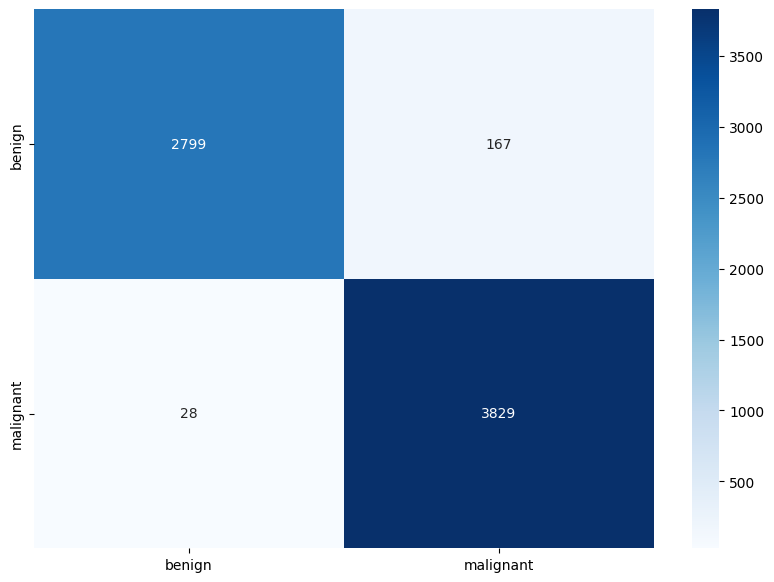

In [15]:
P = model.predict(test_generator)
P = P.squeeze() > 0.5
Y = test_generator.classes

# visualize the confusion matrix
cm = confusion_matrix(Y, P)
df_cm = pd.DataFrame(cm, index = ['benign', 'malignant'], columns = ['benign', 'malignant'])
plt.figure(figsize = (10,7))
heatmap(df_cm, annot=True, cmap='Blues', fmt='g')

# visualize the classification report
print(classification_report(Y, P, target_names = ['benign', 'malignant']))

427/427 [==============================] - 350s 820ms/step


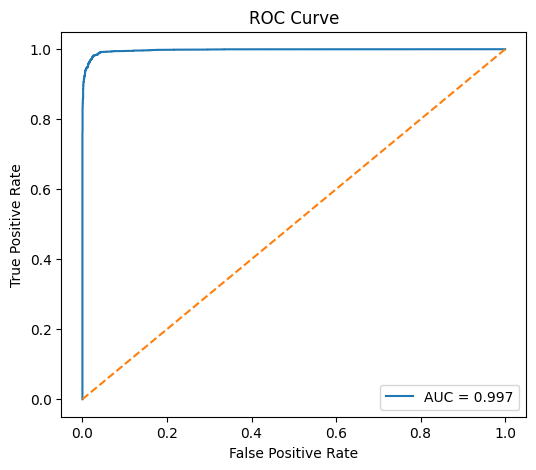

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model.predict(test_generator).ravel()

# True labels
y_true = test_generator.classes

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# AUC score
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
model = tf.keras.models.load_model('cancer_detector.h5')
model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),       
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ])

In [19]:
class_dict = {'benign': 0, 'malignant': 1}
class_dict_rev = {0: 'benign', 1: 'malignant'}

In [20]:
def inference(image_path):
    image_path = image_path.replace('\\', '/')
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, target_size)
    img = np.expand_dims(img, axis=0)
    img = preprocessing_function(img)
    prediction = model.predict(img)
    prediction = np.squeeze(prediction)
    prediction = prediction > 0.5
    prediction = prediction.astype('int')
    prediction = class_dict_rev[prediction]
    return prediction

In [24]:
inference('data/test/benign/20586908 (17).png')

1/1 [==============================] - 0s 170ms/step


'benign'

In [23]:
inference('data/test/malignant/20586934 (5).png')

1/1 [==============================] - 0s 164ms/step


'malignant'